<h1 align="center">2. Modelagem do Grafo, Componentes e Vulnerabilidade</h1>

<h2>1 Grafo</h2>

<h3>1.1 Configuração e Importação dos dados</h3>

In [2]:
!uv pip install pandas
!uv pip install networkx
!uv pip install matplotlib
!uv pip install scipy

Using Python 3.11.15 environment at: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/venv
Checked 1 package in 1ms
Using Python 3.11.15 environment at: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/venv
Checked 1 package in 1ms
Using Python 3.11.15 environment at: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/venv
Checked 1 package in 4ms
Using Python 3.11.15 environment at: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/venv
Checked 1 package in 2ms


In [4]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter
import os
from pathlib import Path

In [5]:
REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'gtfs'
OUTPUT_PATH = REPO_ROOT / 'data' / 'processed'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [ ]:
stop_times = pd.read_csv(DATA_PATH / 'stop_times.txt')
stops = pd.read_csv(DATA_PATH / 'stops.txt')
routes = pd.read_csv(DATA_PATH / 'routes.txt')
trips = pd.read_csv(DATA_PATH / 'trips.txt')

print(f"stop_times: {len(stop_times)} registros")  # sequência ordenada de paradas por viagem (arestas)
print(f"stops:      {len(stops)} registros")   # coordenadas e info das paradas (nós)
print(f"routes:     {len(routes)} registros")  # tipo de modal
print(f"trips:      {len(trips)} registros")   # conecta viagens a rotas (modal de cada viagem)

stop_times: 98423 registros
stops:      22101 registros
routes:     1345 registros
trips:      2254 registros


<h3>1.2 Modal de cada parada</h3>

In [10]:
# 1: Associar cada viagem (trip) ao seu modal (route_type)
trips_com_modal = trips.merge(
    routes[['route_id', 'route_type']],
    on='route_id',
    how='left'
)

# 2: Associar cada registro de stop_times ao modal da viagem
st_com_modal = stop_times.merge(
    trips_com_modal[['trip_id', 'route_type']],
    on='trip_id',
    how='left'
)

# 3: Para cada parada, identificar todos os modais que a servem
# (uma parada pode ser servida por vários modais (possível, mas raro))
parada_modais = st_com_modal.groupby('stop_id')['route_type'].apply(set).reset_index()
parada_modais.columns = ['stop_id', 'modais']

# 4: Classificar cada parada no modal "principal"
# Se tem metrô, é metrô; se tem CPTM, é CPTM; senão, é ônibus
def classificar_modal(modais):
    if 1 in modais:
        return 'metro'
    elif 2 in modais:
        return 'cptm'
    else:
        return 'onibus'

parada_modais['modal'] = parada_modais['modais'].apply(classificar_modal)

print("Paradas por modal:")
print(parada_modais['modal'].value_counts())
print(f"\nTotal: {len(parada_modais):,} paradas com viagens associadas")

Paradas por modal:
modal
onibus    21903
cptm        104
metro        94
Name: count, dtype: int64

Total: 22,101 paradas com viagens associadas


<h3>1.3 Construção do Grafo</h3>

- *L-space*
- não-direcionado
- não-ponderado

In [12]:
# 1: Ordenar por viagem e sequência
st_sorted = stop_times.sort_values(['trip_id', 'stop_sequence'])

# 2: Extrair pares de paradas consecutivas
# set() com frozenset() : evitar duplicatas
# frozenset({A, B}) == frozenset({B, A}) = trata como a mesma aresta

edges_set = set()

for trip_id, group in st_sorted.groupby('trip_id'):
    stop_list = group['stop_id'].values
    for i in range(len(stop_list) - 1):
        edge = frozenset([stop_list[i], stop_list[i + 1]])
        edges_set.add(edge)

print(f"Conexões únicas encontradas: {len(edges_set):,}")

# 3: Criar o grafo NÃO-PONDERADO
G = nx.Graph()
# Filtrar self-loops (arestas onde origem == destino)
arestas_validas = [tuple(e) for e in edges_set if len(e) == 2]
self_loops_removidos = len(edges_set) - len(arestas_validas)

G.add_edges_from(arestas_validas)

print(f"  Self-loops removidos: {self_loops_removidos}")
print(f"  Arestas válidas:      {len(arestas_validas):,}")

# 4: Adicionar atributos aos nós
# Nome e coordenadas vindos de stops.txt
for _, row in stops.iterrows():
    if row['stop_id'] in G.nodes:
        G.nodes[row['stop_id']]['name'] = row['stop_name']
        G.nodes[row['stop_id']]['lat'] = row['stop_lat']
        G.nodes[row['stop_id']]['lon'] = row['stop_lon']

# Modal vem da análise anterior
for _, row in parada_modais.iterrows():
    if row['stop_id'] in G.nodes:
        G.nodes[row['stop_id']]['modal'] = row['modal']


print(f"Nós (paradas):      {G.number_of_nodes():,}")
print(f"Arestas (conexões): {G.number_of_edges():,}")
print(f"Grau médio:         {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"Densidade:          {nx.density(G):.6f}")

Conexões únicas encontradas: 29,556
  Self-loops removidos: 16
  Arestas válidas:      29,540
Nós (paradas):      22,101
Arestas (conexões): 29,540
Grau médio:         2.67
Densidade:          0.000121


"Self-loops são arestas que conectam um nó a ele mesmo, ocorrendo quando duas paradas consecutivas na sequência de uma viagem são a mesma parada. Isso pode acontecer por duplicações no GTFS ou registros de paradas terminais onde o veículo inicia e termina no mesmo ponto. 
Removemos essas arestas porque elas não representam deslocamentos reais entre paradas distintas e poderiam distorcer o cálculo de métricas de centralidade, especialmente as baseadas em caminhos mínimos."

<h3>1.4 Análise dos Componentes do Grafo</h3>

In [13]:
componentes = list(nx.connected_components(G))
n_componentes = len(componentes)

print(f"O grafo tem {n_componentes} componente(s) conexo(s).")

if n_componentes == 1:
    print("O grafo É conexo (é possível se deslocar de qualquer parada a qualquer outra).")
else:
    print(f"O grafo NÃO é conexo (existem {n_componentes} partes desconectadas).")

O grafo tem 14 componente(s) conexo(s).
O grafo NÃO é conexo (existem 14 partes desconectadas).


In [15]:
# Ordenar componentes do maior pro menor
componentes_ord = sorted(componentes, key=len, reverse=True)

# Montar tabela de análise
dados_componentes = []
for i, comp in enumerate(componentes_ord):
    modais_comp = [G.nodes[n].get('modal', 'desconhecido') for n in comp]
    modal_count = Counter(modais_comp)
    modal_principal = modal_count.most_common(1)[0][0]

    dados_componentes.append({
        'componente': i + 1,
        'n_nos': len(comp),
        'pct': len(comp) / G.number_of_nodes() * 100,
        'modal_principal': modal_principal,
        'composicao': dict(modal_count)
    })

df_comp = pd.DataFrame(dados_componentes)
print(df_comp.to_string(index=False))
print(f"\nMaior componente: {df_comp.iloc[0]['n_nos']:,} nós ({df_comp.iloc[0]['pct']:.1f}% da rede)")
print(f"Soma dos demais:  {df_comp.iloc[1:]['n_nos'].sum():,} nós ({df_comp.iloc[1:]['pct'].sum():.1f}% da rede)")

 componente  n_nos       pct modal_principal        composicao
          1  21890 99.045292          onibus {'onibus': 21890}
          2     42  0.190037            cptm      {'cptm': 42}
          3     28  0.126691            cptm      {'cptm': 28}
          4     23  0.104068           metro     {'metro': 23}
          5     18  0.081444           metro     {'metro': 18}
          6     18  0.081444            cptm      {'cptm': 18}
          7     17  0.076920           metro     {'metro': 17}
          8     14  0.063346           metro     {'metro': 14}
          9     13  0.058821            cptm      {'cptm': 13}
         10     11  0.049772           metro     {'metro': 11}
         11     11  0.049772           metro     {'metro': 11}
         12     11  0.049772          onibus    {'onibus': 11}
         13      3  0.013574            cptm       {'cptm': 3}
         14      2  0.009049          onibus     {'onibus': 2}

Maior componente: 21,890 nós (99.0% da rede)
Soma dos 

#### Análise dos componentes menores

In [16]:
# Separar componentes pequenos
componentes_pequenos = componentes_ord[1:]

print(f"{len(componentes_pequenos)} componentes menores:\n")

for i, comp in enumerate(componentes_pequenos):
    subgrafo = G.subgraph(comp)
    graus = [subgrafo.degree(n) for n in comp]
    nomes = [G.nodes[n].get('name', 'N/A') for n in comp]


    print(f"\nCOMPONENTE {i+2} — {len(comp)} nós")

    print(f"\n  Grau mínimo: {min(graus)}")
    print(f"  Grau máximo: {max(graus)}")
    print(f"  Grau médio:  {sum(graus)/len(graus):.2f}")
    print(f"  Distribuição de graus: {dict(Counter(graus))}")
    print(f"  Exemplos de paradas: {nomes[:5]}")
    if len(nomes) > 5:
        print(f"   .. e mais {len(nomes) - 5}")
    print()

13 componentes menores:


COMPONENTE 2 — 42 nós

  Grau mínimo: 1
  Grau máximo: 3
  Grau médio:  1.95
  Distribuição de graus: {2: 38, 3: 1, 1: 3}
  Exemplos de paradas: ['Santa Rita', 'Itapevi', 'Engenheiro Cardoso', 'Sagrado Coração', 'Jandira']
   .. e mais 37


COMPONENTE 3 — 28 nós

  Grau mínimo: 1
  Grau máximo: 3
  Grau médio:  1.93
  Distribuição de graus: {2: 24, 1: 3, 3: 1}
  Exemplos de paradas: ['Aracaré', 'Calmon Viana', 'Itaquaquecetuba', 'Jundiapeba', 'Brás Cubas']
   .. e mais 23


COMPONENTE 4 — 23 nós

  Grau mínimo: 1
  Grau máximo: 2
  Grau médio:  1.91
  Distribuição de graus: {2: 21, 1: 2}
  Exemplos de paradas: ['Conceição', 'Jabaquara', 'São Judas', 'Saúde', 'Praça Da Árvore']
   .. e mais 18


COMPONENTE 5 — 18 nós

  Grau mínimo: 1
  Grau máximo: 2
  Grau médio:  1.89
  Distribuição de graus: {2: 16, 1: 2}
  Exemplos de paradas: ['Tatuapé', 'República', 'Carrão', 'Penha', 'Vila Matilde']
   .. e mais 13


COMPONENTE 6 — 18 nós

  Grau mínimo: 1
  Grau máximo

- distribuição de graus entre 1 e 2 -> essas sub-redes têm estrutura linear (*path graph* / sub-grafo linear)

##### Distribuição de graus

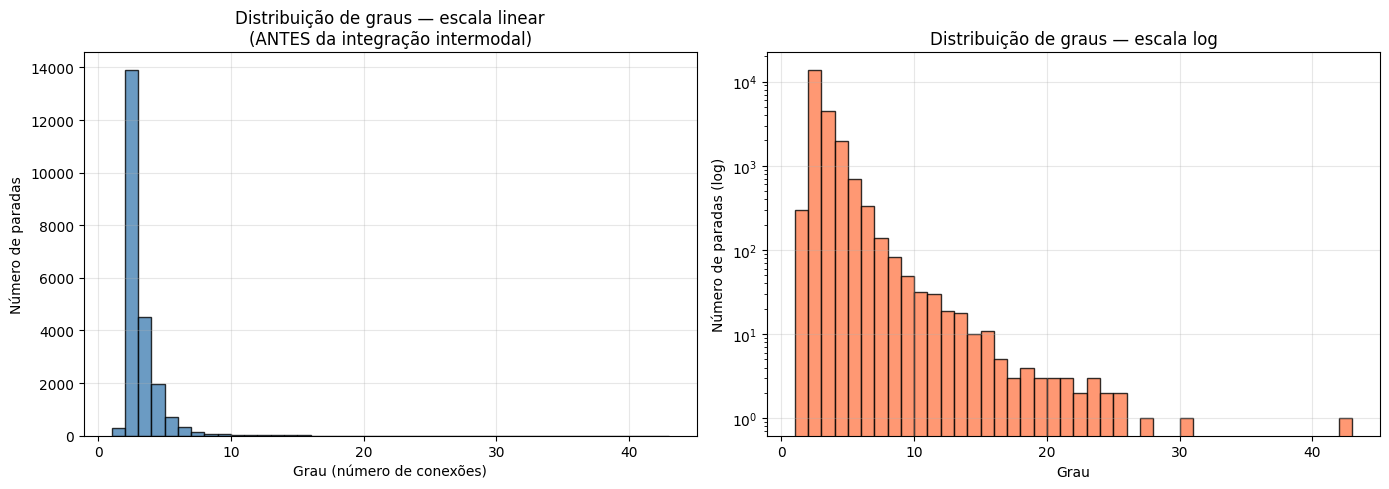


Estatísticas de grau (ANTES da integração):
  Grau mínimo:  1
  Grau máximo:  42
  Grau médio:   2.67
  Grau mediano: 2.0

Top 5 graus mais frequentes:
  Grau 1: 302 paradas (1.4%)
  Grau 2: 13,886 paradas (62.8%)
  Grau 3: 4,500 paradas (20.4%)
  Grau 4: 1,960 paradas (8.9%)
  Grau 5: 695 paradas (3.1%)


In [20]:
# Distribuição de graus do grafo inteiro (antes da integração)

graus_antes = [d for n, d in G.degree()]
contagem_graus = Counter(graus_antes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma linear
axes[0].hist(graus_antes, bins=range(1, max(graus_antes) + 2),
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Grau (número de conexões)')
axes[0].set_ylabel('Número de paradas')
axes[0].set_title('Distribuição de graus — escala linear\n(ANTES da integração intermodal)')
axes[0].grid(alpha=0.3)

# Histograma em log
axes[1].hist(graus_antes, bins=range(1, max(graus_antes) + 2),
             color='coral', edgecolor='black', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Grau')
axes[1].set_ylabel('Número de paradas (log)')
axes[1].set_title('Distribuição de graus — escala log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'hist_graus_antes.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas
print(f"\nEstatísticas de grau (ANTES da integração):")
print(f"  Grau mínimo:  {min(graus_antes)}")
print(f"  Grau máximo:  {max(graus_antes)}")
print(f"  Grau médio:   {np.mean(graus_antes):.2f}")
print(f"  Grau mediano: {np.median(graus_antes):.1f}")
print(f"\nTop 5 graus mais frequentes:")
for grau, cont in sorted(contagem_graus.items())[:5]:
    pct = cont / len(graus_antes) * 100
    print(f"  Grau {grau}: {cont:,} paradas ({pct:.1f}%)")

<h3>1.5 Integração Intermodal</h3>

- criar arestas de transferência

#### 1.5.1 Definição do tamanho do raio

- conversão de metros para graus
- conversão aproximada na latitude de São Paulo (~23.5ºS) é: 1 grau = 111.320 metros
  - 400m = ~0.0036 graus (aproximação válida para distâncias pequenas)

In [22]:
def testar_raio(G_base, raio_metros):
    """
    Parâmetros:
        G_base: grafo original (sem arestas de transferência)
        raio_metros: raio em metros

    Retorna:
        dict com estatísticas
    """
    # Separar nós por modal
    nos_mc = [n for n in G_base.nodes if G_base.nodes[n].get('modal') in ('metro', 'cptm')]
    nos_bus = [n for n in G_base.nodes if G_base.nodes[n].get('modal') == 'onibus']

    # Coordenadas das paradas de ônibus
    coords_bus = np.array([
        [G_base.nodes[n]['lat'], G_base.nodes[n]['lon']]
        for n in nos_bus
    ])

    # Árvore espacial
    tree = cKDTree(coords_bus)

    # Converter metros pra graus
    raio_graus = raio_metros / 111320

    # Criar arestas de transferência
    arestas_novas = []
    for n_mc in nos_mc:
        coord = [G_base.nodes[n_mc]['lat'], G_base.nodes[n_mc]['lon']]
        indices = tree.query_ball_point(coord, raio_graus)
        for idx in indices:
            arestas_novas.append((n_mc, nos_bus[idx]))

    # Aplicar num grafo temporário
    G_teste = G_base.copy()
    G_teste.add_edges_from(arestas_novas)

    # Estatísticas
    n_comp = nx.number_connected_components(G_teste)
    componentes_teste = sorted(nx.connected_components(G_teste), key=len, reverse=True)
    maior_comp = len(componentes_teste[0])

    # Quantas estações receberam pelo menos 1 aresta
    estacoes_conectadas = set([a[0] for a in arestas_novas])

    return {
        'raio_m': raio_metros,
        'n_arestas_novas': len(arestas_novas),
        'n_componentes': n_comp,
        'maior_comp_nos': maior_comp,
        'maior_comp_pct': maior_comp / G_teste.number_of_nodes() * 100,
        'estacoes_conectadas': len(estacoes_conectadas),
        'total_estacoes_mc': len([n for n in G_base.nodes if G_base.nodes[n].get('modal') in ('metro', 'cptm')])
    }

# Testar três raios
resultados = []
for raio in [200, 400, 600]:
    resultado = testar_raio(G, raio)
    resultados.append(resultado)

df_raios = pd.DataFrame(resultados)
print("COMPARAÇÃO DE RAIOS")
print(df_raios.to_string(index=False))
print(f"\nTotal de estações metrô+CPTM: {df_raios.iloc[0]['total_estacoes_mc']}")

COMPARAÇÃO DE RAIOS
 raio_m  n_arestas_novas  n_componentes  maior_comp_nos  maior_comp_pct  estacoes_conectadas  total_estacoes_mc
    200             1308              2           22099       99.990951                  138                198
    400             2624              2           22099       99.990951                  150                198
    600             4877              2           22099       99.990951                  150                198

Total de estações metrô+CPTM: 198.0


##### raio = 400m

In [24]:
RAIO_METROS = 400

# Separar paradas por modal
nos_mc = [n for n in G.nodes if G.nodes[n].get('modal') in ('metro', 'cptm')]
nos_bus = [n for n in G.nodes if G.nodes[n].get('modal') == 'onibus']

print(f"Estações de metrô/CPTM: {len(nos_mc)}")
print(f"Paradas de ônibus:       {len(nos_bus):,}")

# Árvore espacial (só pra paradas de ônibus)
coords_bus = np.array([
    [G.nodes[n]['lat'], G.nodes[n]['lon']]
    for n in nos_bus
])
tree = cKDTree(coords_bus)
raio_graus = RAIO_METROS / 111320

# Criar arestas de transferência
# IMPORTANTE: armazenado em dicionário que registra quantas arestas cada estação ganhou
arestas_transferencia = []
arestas_por_estacao = {}

for n_mc in nos_mc:
    coord = [G.nodes[n_mc]['lat'], G.nodes[n_mc]['lon']]
    indices = tree.query_ball_point(coord, raio_graus)

    arestas_por_estacao[n_mc] = len(indices)

    for idx in indices:
        arestas_transferencia.append((n_mc, nos_bus[idx]))

# Aplicar ao grafo (marcando as arestas como 'transfer' para diferenciação)
G.add_edges_from(arestas_transferencia, tipo='transferencia')

print(f"\nArestas de transferência criadas: {len(arestas_transferencia):,}")
print(f"\nGRAFO APÓS INTEGRAÇÃO:")
print(f"  Nós:        {G.number_of_nodes():,}")
print(f"  Arestas:    {G.number_of_edges():,}")
print(f"  Grau médio: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")

Estações de metrô/CPTM: 198
Paradas de ônibus:       21,903

Arestas de transferência criadas: 2,624

GRAFO APÓS INTEGRAÇÃO:
  Nós:        22,101
  Arestas:    32,164
  Grau médio: 2.91


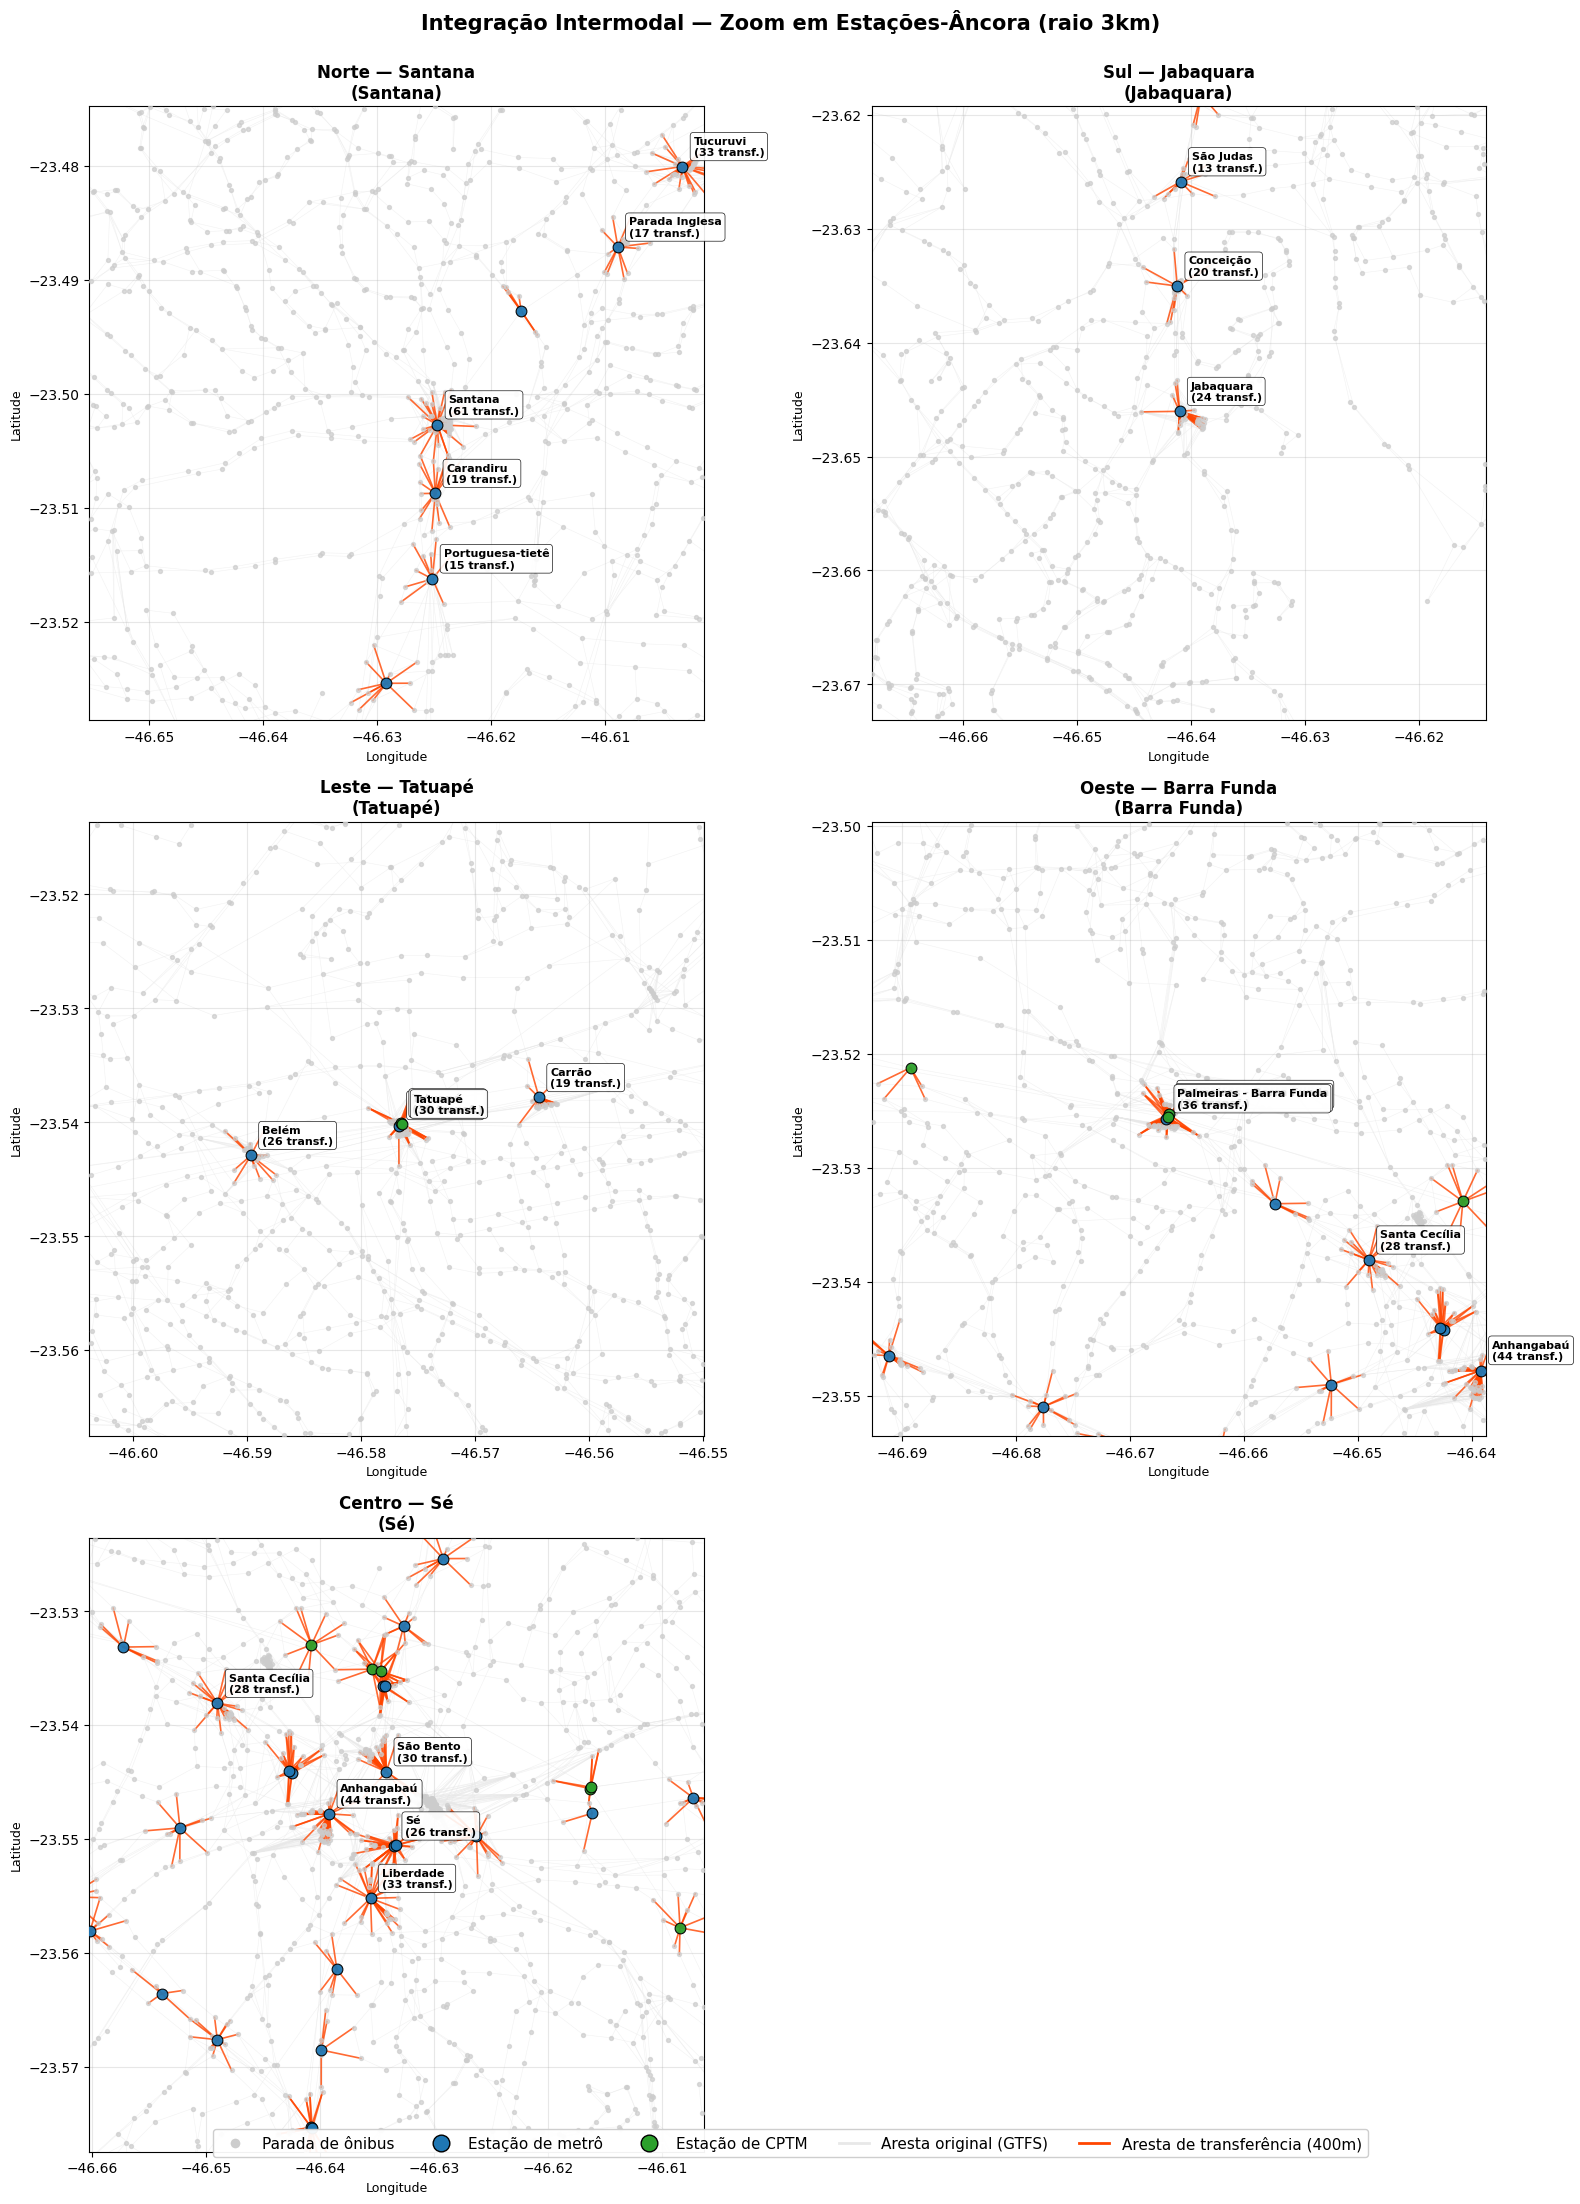


Arestas de transferência por região:
  Norte — Santana: 164 arestas visíveis
  Sul — Jabaquara: 57 arestas visíveis
  Leste — Tatuapé: 136 arestas visíveis
  Oeste — Barra Funda: 280 arestas visíveis
  Centro — Sé: 455 arestas visíveis


In [32]:
# ============================================================
# MAPAS REGIONAIS COM ETIQUETAS: ZOOM EM ESTAÇÕES-ÂNCORA
# ============================================================

from matplotlib.lines import Line2D

# Paleta de cores
COR_ONIBUS = '#cccccc'
COR_METRO = '#1f77b4'
COR_CPTM = '#2ca02c'
COR_TRANSFER = '#ff4500'
COR_ARESTA_NORMAL = '#e8e8e8'

# Lista de arestas originais (sem transferências)
arestas_originais = [
    (u, v) for u, v, d in G.edges(data=True)
    if d.get('tipo') != 'transferencia'
]

# ============================================================
# Estações-âncora com coordenadas diretas
# ============================================================
ancoras_encontradas = {
    'Norte — Santana':     {'nome': 'Santana',     'lat': -23.5017, 'lon': -46.6283},
    'Sul — Jabaquara':     {'nome': 'Jabaquara',   'lat': -23.6462, 'lon': -46.6411},
    'Leste — Tatuapé':     {'nome': 'Tatuapé',     'lat': -23.5406, 'lon': -46.5769},
    'Oeste — Barra Funda': {'nome': 'Barra Funda', 'lat': -23.5266, 'lon': -46.6657},
    'Centro — Sé':         {'nome': 'Sé',          'lat': -23.5505, 'lon': -46.6333}
}

# ============================================================
# Configurações do zoom
# ============================================================
RAIO_ZOOM_KM = 3
RAIO_ZOOM_GRAUS = RAIO_ZOOM_KM / 111.32

# ============================================================
# Função de plotagem
# ============================================================
def plotar_regiao(ax, centro_lat, centro_lon, titulo, grafo, arestas_transfer,
                  arestas_por_estacao, top_n_etiquetas=5):
    """Plota um mapa regional centrado em uma coordenada, com etiquetas nas top N estações."""
    lat_min = centro_lat - RAIO_ZOOM_GRAUS
    lat_max = centro_lat + RAIO_ZOOM_GRAUS
    lon_min = centro_lon - RAIO_ZOOM_GRAUS
    lon_max = centro_lon + RAIO_ZOOM_GRAUS

    # Nós visíveis no bounding box
    nos_visiveis = set()
    for node in grafo.nodes:
        lat = grafo.nodes[node].get('lat')
        lon = grafo.nodes[node].get('lon')
        if lat and lon and lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            nos_visiveis.add(node)

    # Arestas originais (cinza claro)
    for u, v in arestas_originais:
        if u in nos_visiveis or v in nos_visiveis:
            lat_u = grafo.nodes[u].get('lat')
            lon_u = grafo.nodes[u].get('lon')
            lat_v = grafo.nodes[v].get('lat')
            lon_v = grafo.nodes[v].get('lon')
            if lat_u and lat_v:
                ax.plot([lon_u, lon_v], [lat_u, lat_v],
                        color=COR_ARESTA_NORMAL, lw=0.4, alpha=0.6, zorder=1)

    # Arestas de transferência (laranja-vermelho)
    for u, v in arestas_transfer:
        if u in nos_visiveis or v in nos_visiveis:
            lat_u = grafo.nodes[u].get('lat')
            lon_u = grafo.nodes[u].get('lon')
            lat_v = grafo.nodes[v].get('lat')
            lon_v = grafo.nodes[v].get('lon')
            if lat_u and lat_v:
                ax.plot([lon_u, lon_v], [lat_u, lat_v],
                        color=COR_TRANSFER, lw=1.2, alpha=0.8, zorder=2)

    # Nós por modal
    nos_bus = [n for n in nos_visiveis if grafo.nodes[n].get('modal') == 'onibus']
    nos_metro = [n for n in nos_visiveis if grafo.nodes[n].get('modal') == 'metro']
    nos_cptm = [n for n in nos_visiveis if grafo.nodes[n].get('modal') == 'cptm']

    if nos_bus:
        ax.scatter([grafo.nodes[n]['lon'] for n in nos_bus],
                   [grafo.nodes[n]['lat'] for n in nos_bus],
                   c=COR_ONIBUS, s=8, alpha=0.7, zorder=3)
    if nos_metro:
        ax.scatter([grafo.nodes[n]['lon'] for n in nos_metro],
                   [grafo.nodes[n]['lat'] for n in nos_metro],
                   c=COR_METRO, s=60, alpha=0.95,
                   edgecolors='black', linewidths=0.8, zorder=5)
    if nos_cptm:
        ax.scatter([grafo.nodes[n]['lon'] for n in nos_cptm],
                   [grafo.nodes[n]['lat'] for n in nos_cptm],
                   c=COR_CPTM, s=60, alpha=0.95,
                   edgecolors='black', linewidths=0.8, zorder=5)

    # Etiquetas nas top N estações por nº de arestas de transferência
    estacoes_visiveis = [n for n in nos_visiveis
                         if grafo.nodes[n].get('modal') in ('metro', 'cptm')]
    estacoes_ranqueadas = sorted(
        estacoes_visiveis,
        key=lambda n: arestas_por_estacao.get(n, 0),
        reverse=True
    )
    top_estacoes = estacoes_ranqueadas[:top_n_etiquetas]

    for node in top_estacoes:
        nome = grafo.nodes[node].get('name', '')
        lat = grafo.nodes[node]['lat']
        lon = grafo.nodes[node]['lon']
        n_arestas = arestas_por_estacao.get(node, 0)

        ax.annotate(
            f"{nome}\n({n_arestas} transf.)",
            xy=(lon, lat),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.9
            ),
            zorder=10
        )

    # Eixos
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

# ============================================================
# Plotar os 5 mapas em grade 3x2
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes = axes.flatten()

for i, (regiao, info) in enumerate(ancoras_encontradas.items()):
    titulo = f"{regiao}\n({info['nome']})"
    plotar_regiao(
        axes[i],
        info['lat'],
        info['lon'],
        titulo,
        G,
        arestas_transferencia,
        arestas_por_estacao,
        top_n_etiquetas=5
    )

# Esconder o 6º subplot vazio
axes[5].axis('off')

# Legenda única
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COR_ONIBUS,
           markersize=8, label='Parada de ônibus'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COR_METRO,
           markeredgecolor='black', markersize=12, label='Estação de metrô'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COR_CPTM,
           markeredgecolor='black', markersize=12, label='Estação de CPTM'),
    Line2D([0], [0], color=COR_ARESTA_NORMAL, lw=2, label='Aresta original (GTFS)'),
    Line2D([0], [0], color=COR_TRANSFER, lw=2, label='Aresta de transferência (400m)')
]
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.02), ncol=5, fontsize=11, framealpha=0.95)

plt.suptitle(f'Integração Intermodal — Zoom em Estações-Âncora (raio {RAIO_ZOOM_KM}km)',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'mapas_regionais_integracao.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas por região
print("\nArestas de transferência por região:")
for regiao, info in ancoras_encontradas.items():
    lat_c = info['lat']
    lon_c = info['lon']
    count = 0
    for u, v in arestas_transferencia:
        lat_u = G.nodes[u].get('lat')
        lon_u = G.nodes[u].get('lon')
        if lat_u and lon_u:
            if (abs(lat_u - lat_c) < RAIO_ZOOM_GRAUS and
                abs(lon_u - lon_c) < RAIO_ZOOM_GRAUS):
                count += 1
    print(f"  {regiao}: {count} arestas visíveis")

<h3>Métricas de Centralidade</h3>

<h2 align="center">Vulnerabilidade</h2>